## Machine Learning Classification Project Guide


**Project Title: Online Exam Cheating Risk Detection System**

**Introduction**


With the growing adoption of online examinations across educational institutions and EdTech platforms,
maintaining academic integrity has become a major concern. Students may engage in various forms of unfair
practices such as switching browser tabs, disabling monitoring systems, device switching, or attempting
copy-paste actions during online assessments.
This project aims to develop a Machine Learning classification model that predicts the likelihood of cheating
behavior based on structured examination activity logs and interaction patterns captured during the assessment.

**Expected Outcome**

The expected outcome of this project is to develop a predictive system capable of identifying high-risk cheating
behavior during an online examination. The trained model can be used by institutions to trigger real-time alerts,
initiate monitoring interventions, and improve examination integrity by taking preventive actions before unfair
practices impact the evaluation process.

**Project Workflow**

**EDA Steps**

In [26]:
import pandas as pd

In [27]:
df=pd.read_csv("Downloads/online_exam_cheating_risk_dataset.csv");

**Step 1: Data Understanding**

Perform an initial overview of the dataset using head(), info(), and describe() methods to understand the structure,
data types, and summary statistics.

In [28]:
df.head()

,exam_duration_minutes,time_taken_to_start,tab_switch_count,fullscreen_exit_count,copy_paste_attempts,device_switch_count,ip_address_change,mouse_movement_speed,inactivity_time,question_skip_count,revisits_count,login_attempts,network_instability,webcam_disabled_flag,background_noise_flag,exam_time_remaining,typing_speed,answer_change_count,suspicious_activity_score,cheating_risk
0,60,3,3,1,1,0,0,595,138,4,19,4,0,0,0,25,41,1,9,1
1,86,4,5,0,0,0,0,554,102,6,8,4,2,0,0,18,41,11,9,1
2,58,8,3,1,0,1,0,703,125,5,16,1,1,0,0,27,37,11,6,1
3,40,0,5,1,3,0,0,390,82,1,0,2,0,0,0,25,36,7,11,0
4,36,9,5,2,1,1,0,686,224,8,23,4,0,1,1,14,41,14,13,1


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   exam_duration_minutes      12000 non-null  int64
 1   time_taken_to_start        12000 non-null  int64
 2   tab_switch_count           12000 non-null  int64
 3   fullscreen_exit_count      12000 non-null  int64
 4   copy_paste_attempts        12000 non-null  int64
 5   device_switch_count        12000 non-null  int64
 6   ip_address_change          12000 non-null  int64
 7   mouse_movement_speed       12000 non-null  int64
 8   inactivity_time            12000 non-null  int64
 9   question_skip_count        12000 non-null  int64
 10  revisits_count             12000 non-null  int64
 11  login_attempts             12000 non-null  int64
 12  network_instability        12000 non-null  int64
 13  webcam_disabled_flag       12000 non-null  int64
 14  background_noise_flag 

In [30]:
df.describe()

,exam_duration_minutes,time_taken_to_start,tab_switch_count,fullscreen_exit_count,copy_paste_attempts,device_switch_count,ip_address_change,mouse_movement_speed,inactivity_time,question_skip_count,revisits_count,login_attempts,network_instability,webcam_disabled_flag,background_noise_flag,exam_time_remaining,typing_speed,answer_change_count,suspicious_activity_score,cheating_risk
count,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000
mean,61.704833,3.41825,4.435167,1.424833,0.653750,0.258583,0.086833,529.420583,90.94550,4.180917,13.747000,1.690083,0.780083,0.124167,0.168917,15.826667,40.32200,9.361000,8.462417,0.500000
std,24.498869,2.54536,2.193102,1.247055,0.785013,0.524475,0.281602,99.738964,39.98765,3.817294,9.830101,1.017655,0.962703,0.329785,0.374694,9.664345,6.24471,7.239041,3.079076,0.500021
min,30.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,173.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,19.00000,0.000000,1.000000,0.000000
25%,41.000000,1.00000,3.000000,0.000000,0.000000,0.000000,0.000000,461.000000,62.00000,1.000000,6.000000,1.000000,0.000000,0.000000,0.000000,9.000000,36.00000,3.000000,6.000000,0.000000
50%,60.000000,3.00000,4.000000,1.000000,0.000000,0.000000,0.000000,527.000000,87.00000,4.000000,13.000000,1.000000,1.000000,0.000000,0.000000,16.000000,40.00000,9.000000,8.000000,0.500000
75%,79.000000,5.00000,6.000000,2.000000,1.000000,0.000000,0.000000,595.000000,115.00000,7.000000,20.000000,2.000000,1.000000,0.000000,0.000000,22.000000,45.00000,14.000000,10.000000,1.000000
max,171.000000,13.00000,13.000000,6.000000,5.000000,4.000000,1.000000,950.000000,302.00000,22.000000,60.000000,8.000000,6.000000,1.000000,1.000000,57.000000,62.00000,42.000000,23.000000,1.000000


**Step 2: Univariate Analysis**

Analyze each feature individually using appropriate plots (histograms, bar charts, box plots) and summary
statistics. Identify distributions, outliers, and unusual patterns.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 640x480 with 0 Axes>

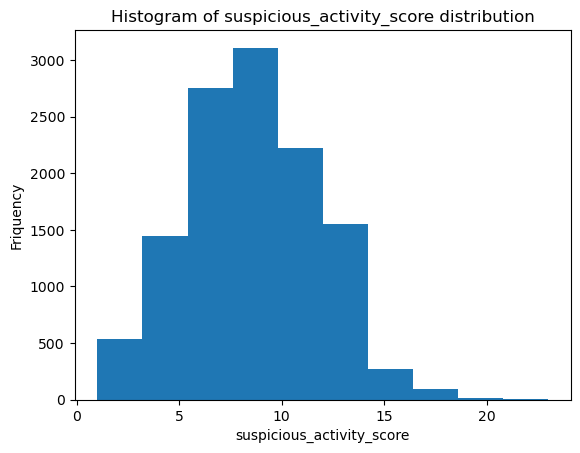

<Figure size 640x480 with 0 Axes>

In [31]:
plt.hist(df["suspicious_activity_score"],bins=10)
plt.title("Histogram of suspicious_activity_score distribution")
plt.xlabel("suspicious_activity_score")
plt.ylabel('Friquency')
plt.figure()

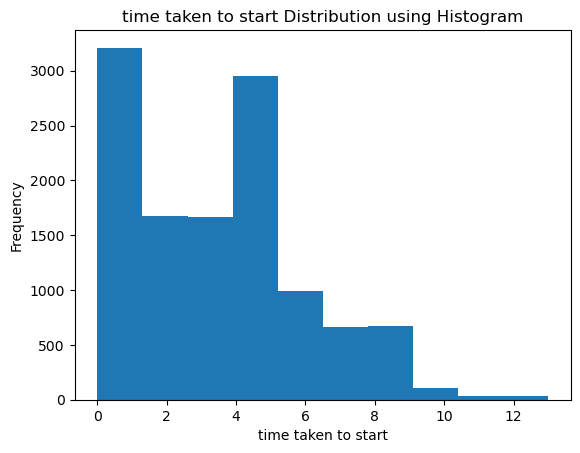

In [13]:
plt.hist(df["time_taken_to_start"])
plt.title("time taken to start Distribution using Histogram")
plt.xlabel("time taken to start")
plt.ylabel("Frequency")
plt.show()

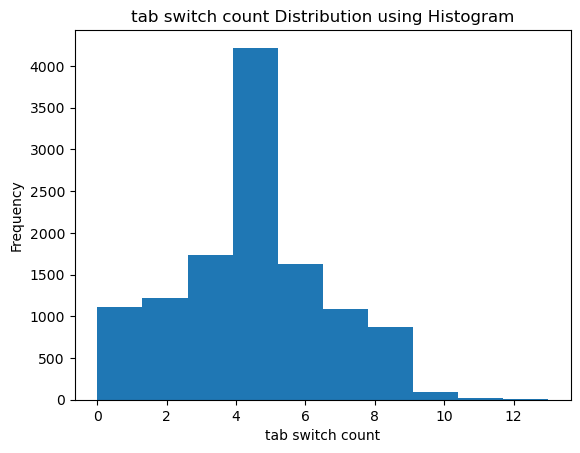

In [15]:
plt.hist(df["tab_switch_count"])
plt.title("tab switch count Distribution using Histogram")
plt.xlabel("tab switch count")
plt.ylabel("Frequency")
plt.show()

<Figure size 640x480 with 0 Axes>

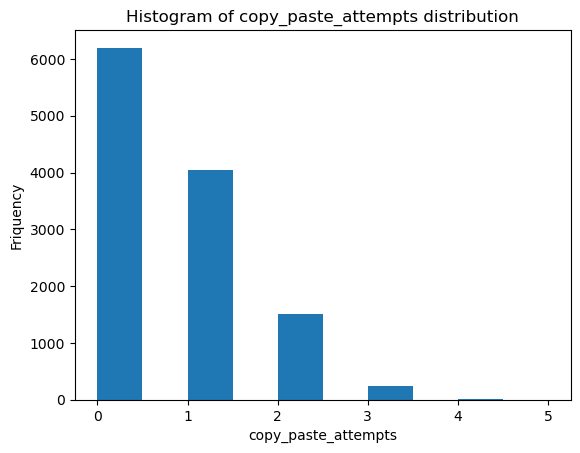

<Figure size 640x480 with 0 Axes>

In [33]:
plt.hist(df["copy_paste_attempts"],bins=10)
plt.title("Histogram of copy_paste_attempts distribution")
plt.xlabel("copy_paste_attempts")
plt.ylabel('Friquency')
plt.figure()

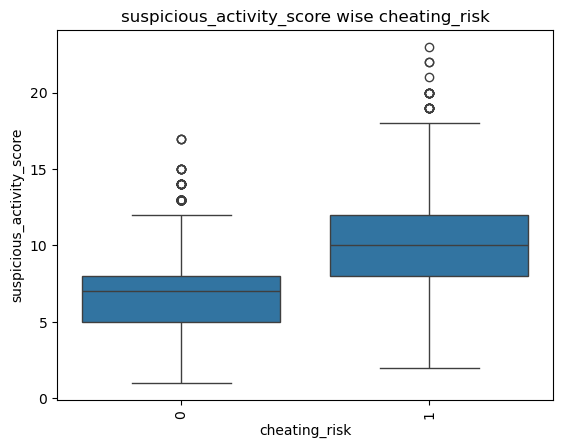

In [32]:
sns.boxplot(x="cheating_risk", y="suspicious_activity_score", data=df)
plt.title("suspicious_activity_score wise cheating_risk")
plt.xlabel("cheating_risk")
plt.ylabel("suspicious_activity_score")
plt.xticks(rotation = 90)
plt.show()

## Step 3: Bivariate Analysis

Perform feature-to-feature analysis across all meaningful pairs. Use scatter plots, grouped aggregations, and
comparative plots to understand relationships and dependencies between variables.

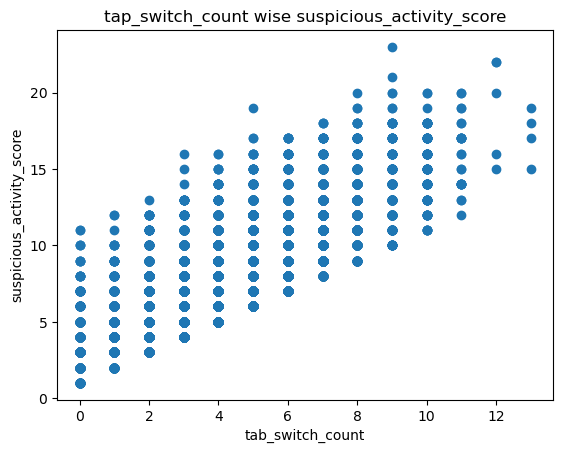

In [35]:
plt.scatter(df["tab_switch_count"],df["suspicious_activity_score"])
plt.xlabel("tab_switch_count")
plt.ylabel("suspicious_activity_score")
plt.title("tap_switch_count wise suspicious_activity_score")
plt.show()

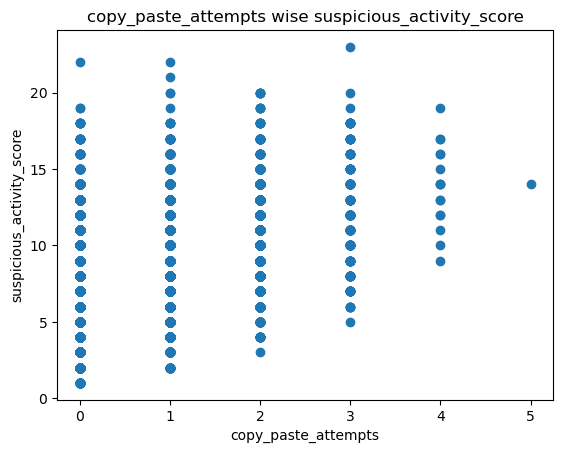

In [36]:
plt.scatter(df["copy_paste_attempts"],df["suspicious_activity_score"])
plt.xlabel("copy_paste_attempts")
plt.ylabel("suspicious_activity_score")
plt.title("copy_paste_attempts wise suspicious_activity_score")
plt.show()

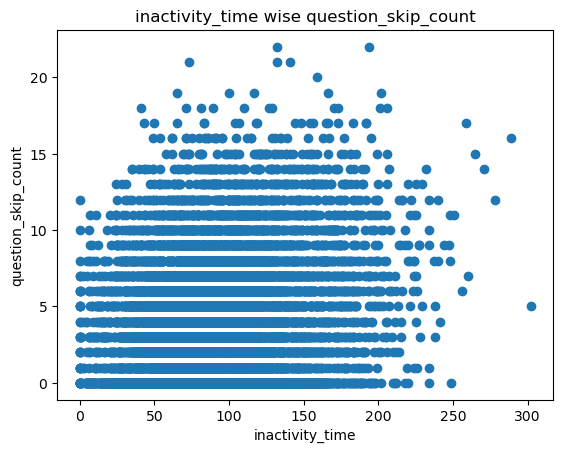

In [37]:
plt.scatter(df["inactivity_time"],df["question_skip_count"])
plt.xlabel("inactivity_time")
plt.ylabel("question_skip_count")
plt.title("inactivity_time wise question_skip_count")
plt.show()

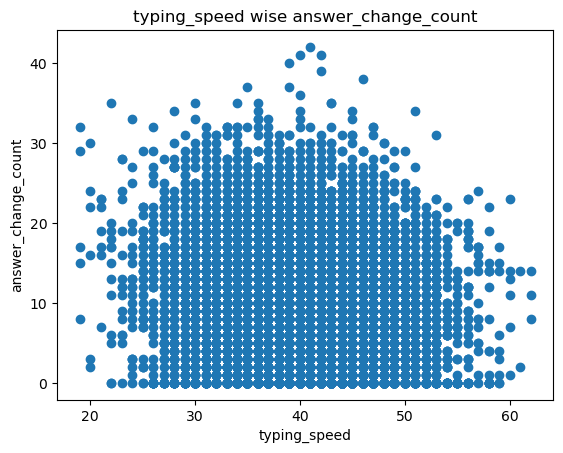

In [38]:
plt.scatter(df["typing_speed"],df["answer_change_count"])
plt.xlabel("typing_speed")
plt.ylabel("answer_change_count")
plt.title("typing_speed wise answer_change_count")
plt.show()

In [39]:
df.groupby('tab_switch_count')['suspicious_activity_score'].mean()

tab_switch_count
0      3.702760
1      4.713396
2      5.942292
3      6.913545
4      7.937734
5      9.014890
6     10.091636
7     11.271560
8     12.457655
9     13.440613
10    14.968421
11    15.923077
12    19.000000
13    17.250000
Name: suspicious_activity_score, dtype: float64

In [40]:
df.groupby('device_switch_count')['inactivity_time'].mean()

device_switch_count
0     87.038297
1    102.016036
2    117.798913
3    133.882353
4    156.800000
Name: inactivity_time, dtype: float64

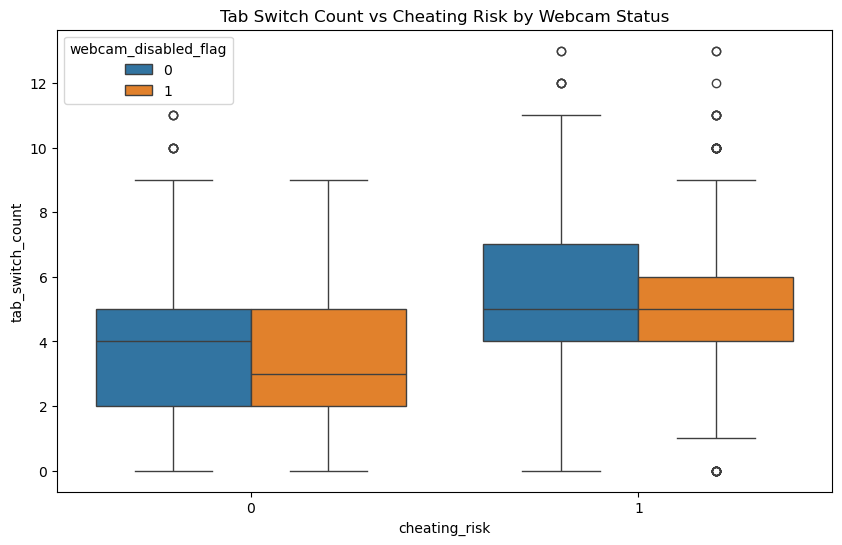

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(x="cheating_risk",y="tab_switch_count",hue="webcam_disabled_flag",data=df)
plt.title("Tab Switch Count vs Cheating Risk by Webcam Status")
plt.show()

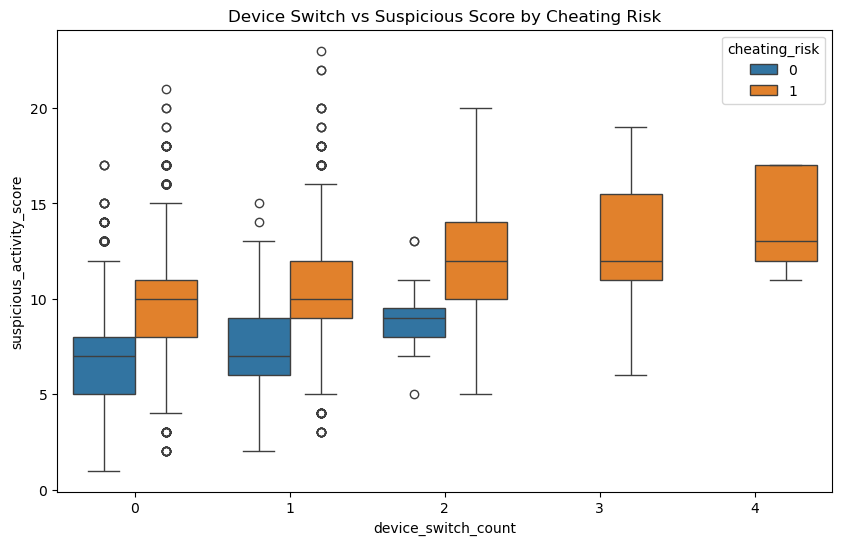

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(x="device_switch_count",y="suspicious_activity_score",hue="cheating_risk",data=df)
plt.title("Device Switch vs Suspicious Score by Cheating Risk")
plt.show()

## Step 4: Target Relationship Analysis

Evaluate how each feature relates to the target variable using suitable visualizations and grouped statistics.
Repeat this for every feature.

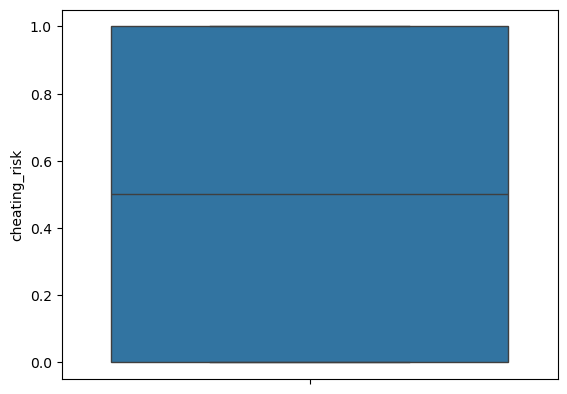

In [43]:
sns.boxplot(y=df['cheating_risk'])
plt.show()

## Step 5: Multivariate Analysis

Use correlation heatmaps and other multivariate techniques to identify the strongest combined relationships
among features.

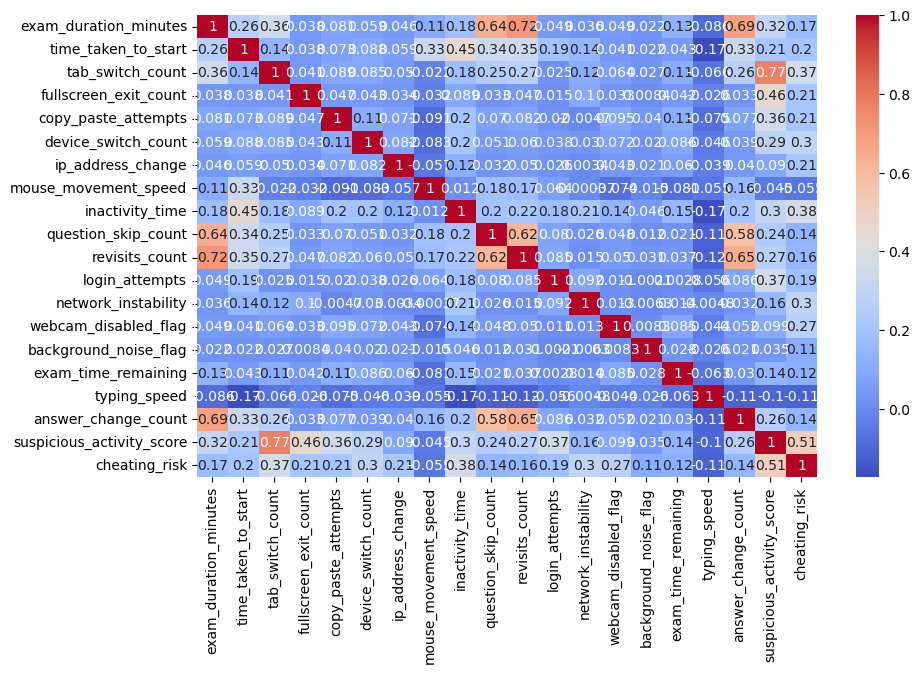

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

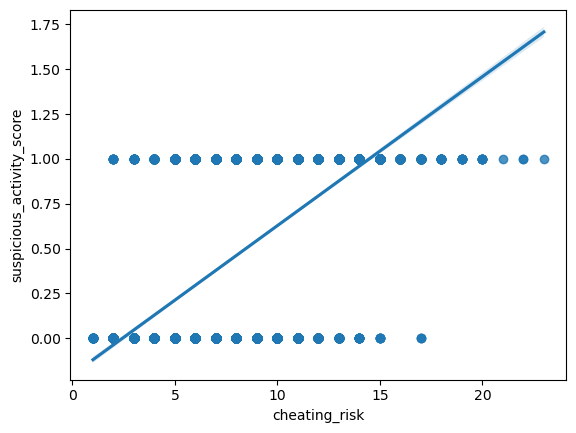

In [45]:
sns.regplot(x="suspicious_activity_score",y="cheating_risk",data=df)
plt.ylabel("suspicious_activity_score")
plt.xlabel("cheating_risk")
plt.show()  

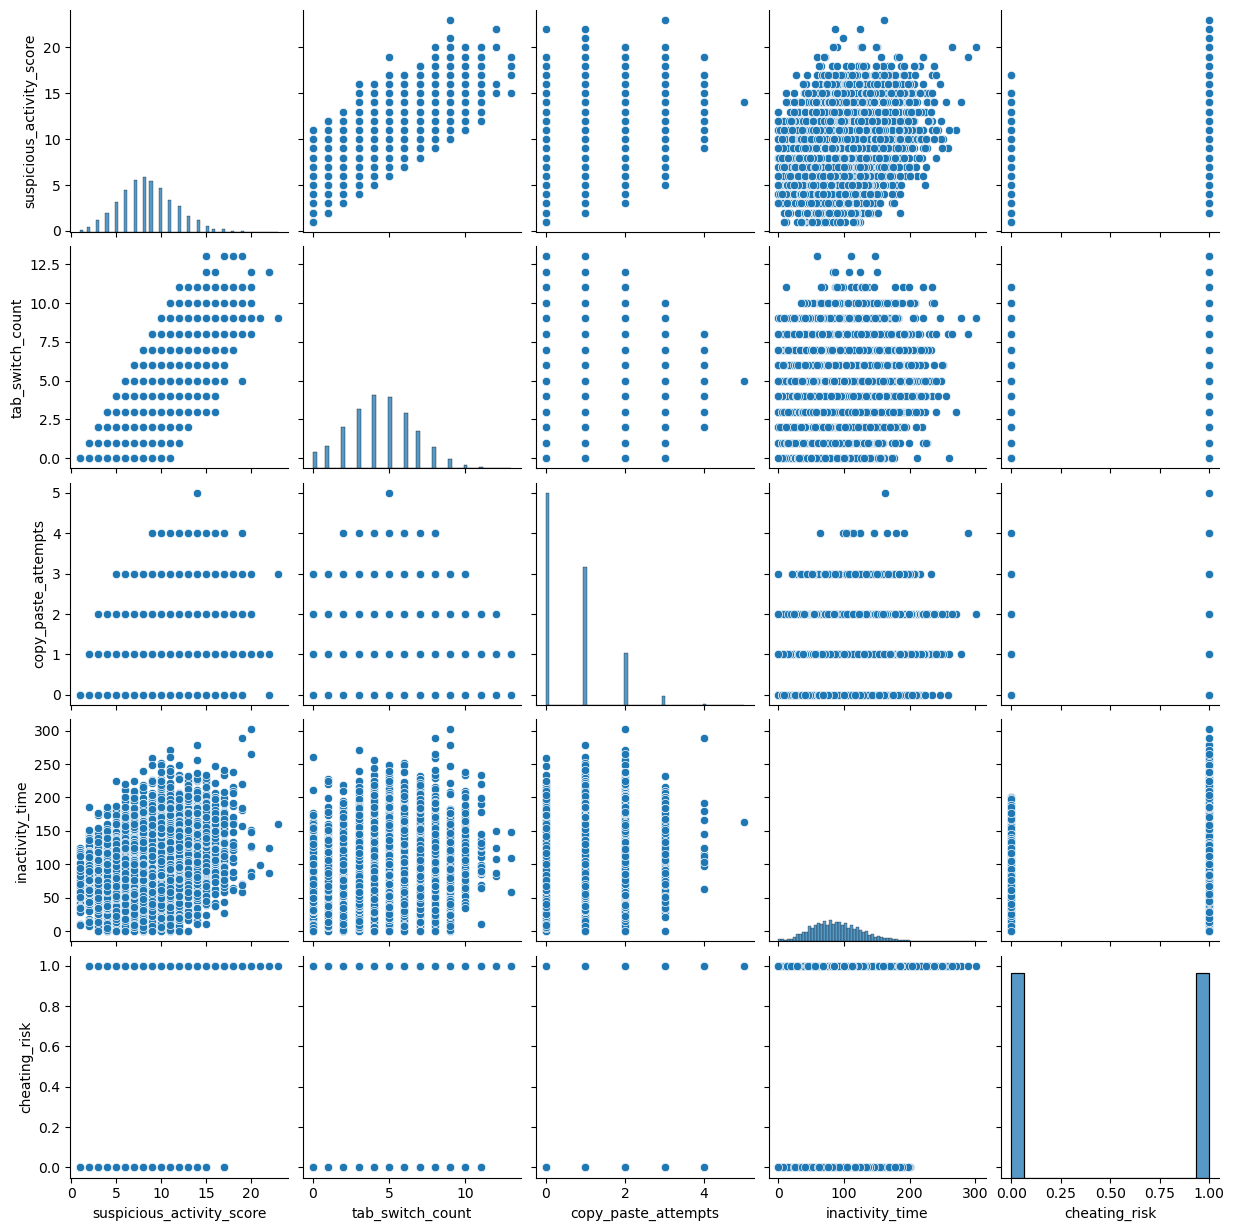

In [46]:
sns.pairplot(df[["suspicious_activity_score","tab_switch_count","copy_paste_attempts","inactivity_time","cheating_risk"]])
plt.show()

## Step 6: Data Preprocessing

Handle missing values, encode categorical/binary variables where required, and scale numerical features if
needed.

In [47]:
df.isnull().sum()

exam_duration_minutes        0
time_taken_to_start          0
tab_switch_count             0
fullscreen_exit_count        0
copy_paste_attempts          0
device_switch_count          0
ip_address_change            0
mouse_movement_speed         0
inactivity_time              0
question_skip_count          0
revisits_count               0
login_attempts               0
network_instability          0
webcam_disabled_flag         0
background_noise_flag        0
exam_time_remaining          0
typing_speed                 0
answer_change_count          0
suspicious_activity_score    0
cheating_risk                0
dtype: int64

In [48]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
ch=df["cheating_risk"]
ch_encoded = encoder.fit_transform(ch)
print(ch_encoded)
print("Mapping:",dict(zip(encoder.classes_, range(len(encoder.classes_)))))

[1 1 1 ... 0 1 1]
Mapping: {np.int64(0): 0, np.int64(1): 1}


## Step 7: Feature Engineering

Create new meaningful features based on domain understanding (example: combining multiple activity indicators
into a single score).

In [50]:
df["behavioral_risk_score"] = (
    df["tab_switch_count"] +
    df["fullscreen_exit_count"] +
    df["copy_paste_attempts"] +
    df["device_switch_count"] +
    df["ip_address_change"]
)
df.head()

,exam_duration_minutes,time_taken_to_start,tab_switch_count,fullscreen_exit_count,copy_paste_attempts,device_switch_count,ip_address_change,mouse_movement_speed,inactivity_time,question_skip_count,...,login_attempts,network_instability,webcam_disabled_flag,background_noise_flag,exam_time_remaining,typing_speed,answer_change_count,suspicious_activity_score,cheating_risk,behavioral_risk_score
0,60,3,3,1,1,0,0,595,138,4,...,4,0,0,0,25,41,1,9,1,5
1,86,4,5,0,0,0,0,554,102,6,...,4,2,0,0,18,41,11,9,1,5
2,58,8,3,1,0,1,0,703,125,5,...,1,1,0,0,27,37,11,6,1,5
3,40,0,5,1,3,0,0,390,82,1,...,2,0,0,0,25,36,7,11,0,9
4,36,9,5,2,1,1,0,686,224,8,...,4,0,1,1,14,41,14,13,1,9


In [53]:
print(df.isnull().sum())

exam_duration_minutes        0
time_taken_to_start          0
tab_switch_count             0
fullscreen_exit_count        0
copy_paste_attempts          0
device_switch_count          0
ip_address_change            0
mouse_movement_speed         0
inactivity_time              0
question_skip_count          0
revisits_count               0
login_attempts               0
network_instability          0
webcam_disabled_flag         0
background_noise_flag        0
exam_time_remaining          0
typing_speed                 0
answer_change_count          0
suspicious_activity_score    0
cheating_risk                0
behavioral_risk_score        0
dtype: int64


In [52]:
df = df[df["cheating_risk"].notnull()]

In [54]:
x= df.drop("cheating_risk", axis=1)
y= df["cheating_risk"]

## Step 8: Train-Test Split

Split the dataset into training and testing sets using stratified sampling.

In [56]:
from sklearn. model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Traning set size:", x_train.shape)   
print("Test set size:", x_test.shape)
print("cheating_risk distribution in Train:\n", y_train.value_counts(normalize=True))
print("sheating_risk distribution in Test:\n", y_test.value_counts(normalize=True))

Traning set size: (9600, 20)
Test set size: (2400, 20)
cheating_risk distribution in Train:
 cheating_risk
0    0.5
1    0.5
Name: proportion, dtype: float64
sheating_risk distribution in Test:
 cheating_risk
0    0.5
1    0.5
Name: proportion, dtype: float64


In [57]:
print(y_test.isnull().sum())

0


In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Step 10: Model Evaluation

Evaluate models using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, and Confusion Matrix. Compare
results and select the best-performing model.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(x_train, y_train)

y_pred = log_reg.predict(x_test)
y_prob = log_reg.predict_proba(x_test)[:, 1]

In [60]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8245833333333333


In [61]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.81      0.85      0.83      1200
           1       0.84      0.80      0.82      1200

    accuracy                           0.82      2400
   macro avg       0.83      0.82      0.82      2400
weighted avg       0.83      0.82      0.82      2400



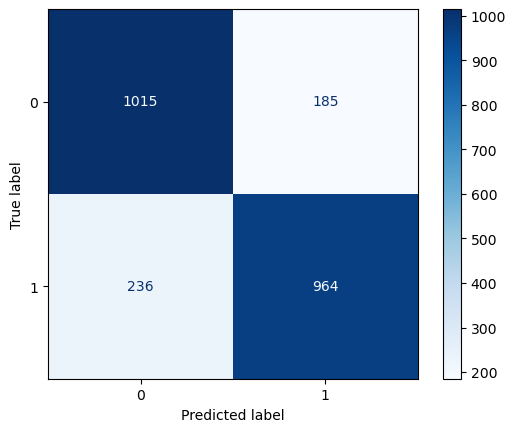

In [62]:
ConfusionMatrixDisplay.from_estimator(log_reg, x_test, y_test,cmap="Blues")
plt.show()

In [63]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.9058715277777778


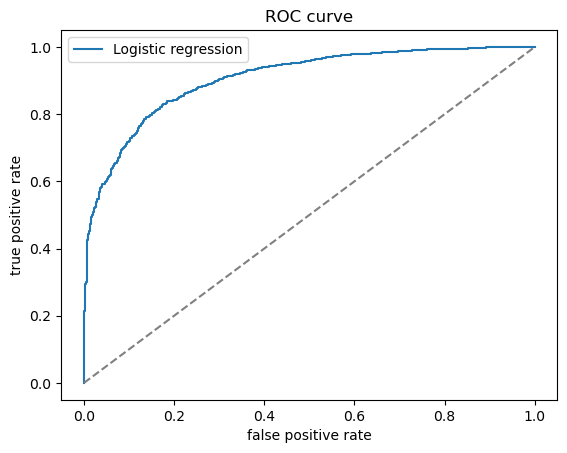

In [64]:
from sklearn.metrics import roc_curve


fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="Logistic regression")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [65]:
#Decision tree classifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

dec_cla =  DecisionTreeClassifier(random_state=42)

dec_cla.fit(x_train, y_train)

y_pred = dec_cla.predict(x_test)
y_prob = dec_cla.predict_proba(x_test)[:, 1] 

In [66]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.7366666666666667


In [67]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.74      0.74      0.74      1200
           1       0.74      0.73      0.74      1200

    accuracy                           0.74      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.74      0.74      0.74      2400



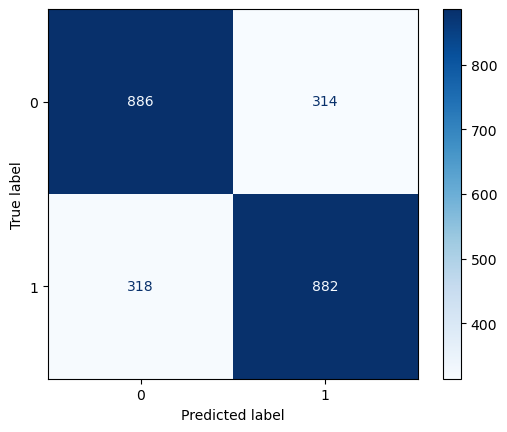

In [68]:
ConfusionMatrixDisplay.from_estimator(dec_cla, x_test, y_test,cmap="Blues")
plt.show()

In [69]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.7366666666666666


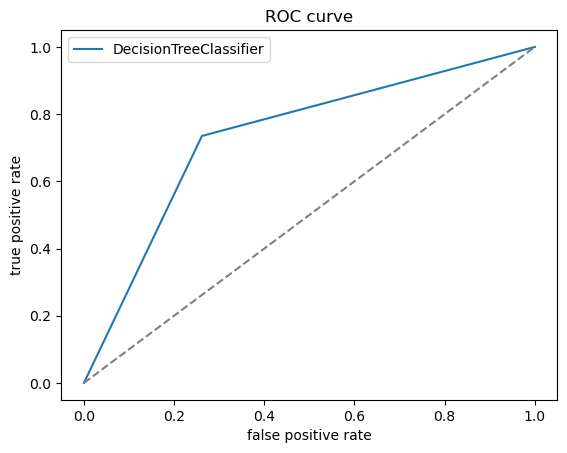

In [70]:
from sklearn.metrics import roc_curve


fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="DecisionTreeClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [71]:
#Random forest classifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score
ra_cla = RandomForestClassifier(random_state=42)

ra_cla.fit(x_train, y_train)

y_pred = ra_cla.predict(x_test)
y_prob = ra_cla.predict_proba(x_test)[:, 1]

In [72]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8075


In [73]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.81      0.81      0.81      1200
           1       0.81      0.81      0.81      1200

    accuracy                           0.81      2400
   macro avg       0.81      0.81      0.81      2400
weighted avg       0.81      0.81      0.81      2400



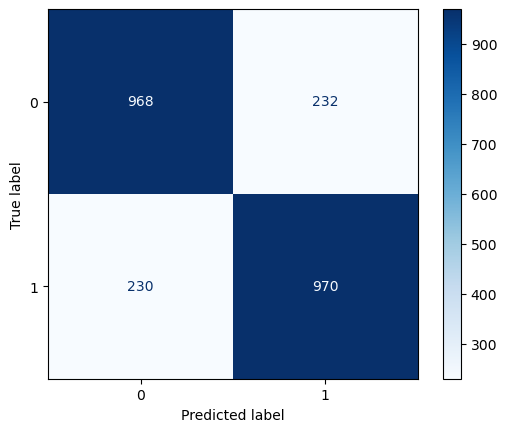

In [74]:
ConfusionMatrixDisplay.from_estimator(ra_cla,x_test,y_test,cmap="Blues")
plt.show()

In [75]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8909961805555556


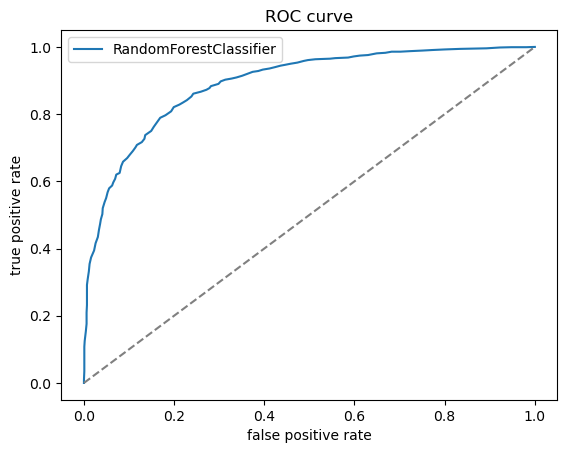

In [76]:
from sklearn.metrics import roc_curve

fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="RandomForestClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [77]:
#Gradient boosting classifier 
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

gra_bo_cla = GradientBoostingClassifier(random_state=42)

gra_bo_cla.fit(x_train, y_train)

y_pred = gra_bo_cla.predict(x_test)
y_prob = gra_bo_cla.predict_proba(x_test)[:, 1] 

In [78]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.81375


In [79]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.81      0.82      0.82      1200
           1       0.82      0.80      0.81      1200

    accuracy                           0.81      2400
   macro avg       0.81      0.81      0.81      2400
weighted avg       0.81      0.81      0.81      2400



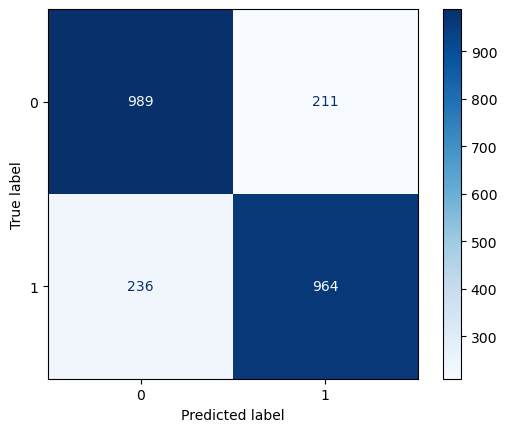

In [80]:
ConfusionMatrixDisplay.from_estimator(gra_bo_cla,x_test,y_test,cmap="Blues")
plt.show()

In [81]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.900878125


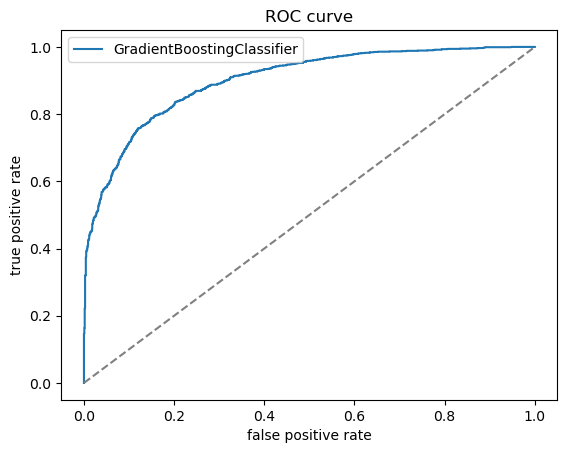

In [82]:
from sklearn.metrics import roc_curve

fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="GradientBoostingClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [87]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 479.4 kB/s eta 0:03:31
   ---------------------------------------- 0.8/101.7 MB 580.1 kB/s eta 0:02:54
   ---------------------------------------- 1.0/101.7 MB 684.5 kB/s eta 0:02:28
   ---------------------------------------- 1.0/101.7 MB 684.5 kB/s eta 0:02:28
    --------------------------------------- 1.3/101.7 MB 750.8 kB/s eta 0:02:14
    --------------------------------------- 1.3/101.7 MB 750.8 kB/s eta 0:02:14
    ------------

In [88]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

XGBCla= XGBClassifier(random_state=42)

XGBCla.fit(x_train, y_train)

y_pred = XGBCla.predict(x_test)
y_prob = XGBCla.predict_proba(x_test)[:, 1] 

In [89]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8025


In [90]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.80      0.81      0.80      1200
           1       0.81      0.80      0.80      1200

    accuracy                           0.80      2400
   macro avg       0.80      0.80      0.80      2400
weighted avg       0.80      0.80      0.80      2400



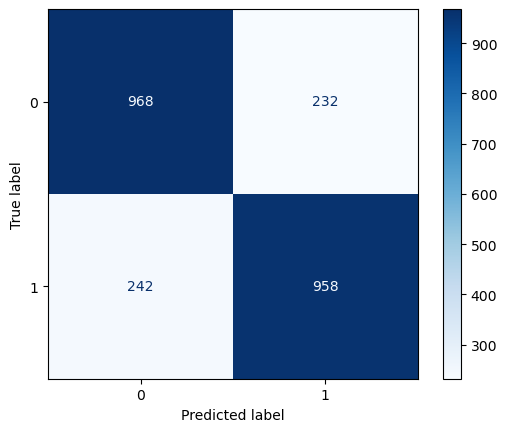

In [91]:
ConfusionMatrixDisplay.from_estimator(XGBCla,x_test,y_test,cmap="Blues")
plt.show()

In [92]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8862513888888889


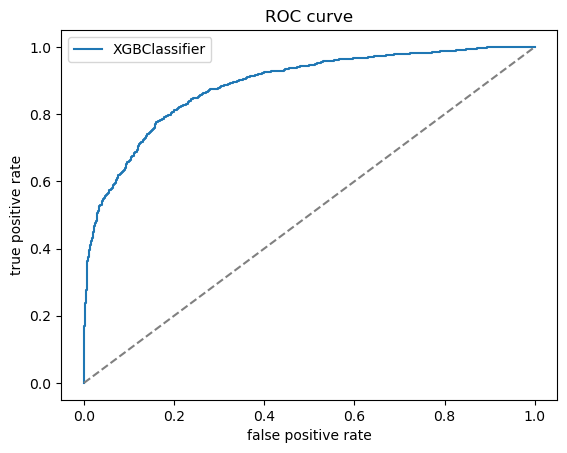

In [93]:
from sklearn.metrics import roc_curve

fpr, tpr, _=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="XGBClassifier")
plt.plot([0,1],[0,1],'--',color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [94]:
#KNN classifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score

KNNCla = KNeighborsClassifier()
KNNCla.fit(x_train, y_train)

y_pred = KNNCla.predict(x_test)
y_prob = KNNCla.predict_proba(x_test)[:, 1] 

In [95]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.7804166666666666


In [96]:
print("Classification Report:/n", classification_report(y_test, y_pred))

Classification Report:/n               precision    recall  f1-score   support

           0       0.76      0.82      0.79      1200
           1       0.80      0.74      0.77      1200

    accuracy                           0.78      2400
   macro avg       0.78      0.78      0.78      2400
weighted avg       0.78      0.78      0.78      2400



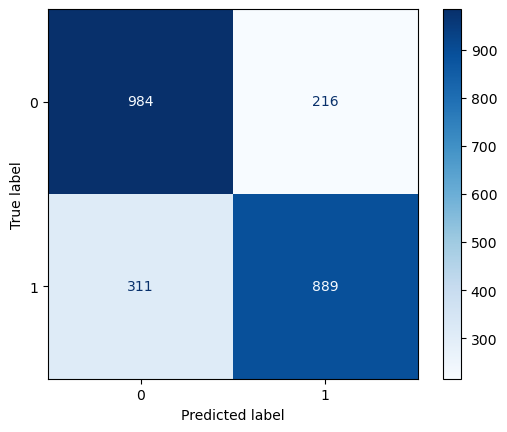

In [97]:
ConfusionMatrixDisplay.from_estimator(KNNCla,x_test,y_test,cmap="Blues")
plt.show()